In [1]:
import os
import re
import math
import random
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.attention.flex_attention import flex_attention, create_block_mask
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython import display
torch.manual_seed(69)
torch.set_printoptions(profile="short", sci_mode=False, linewidth=100000)
torch.set_float32_matmul_precision('high')
# this script is configured to run on a RTX 3060 12GB GPU. you'll want to adjust the model sizes and batch sizes for other devices
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
# device = torch.device('cpu')
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['figure.dpi'] = 50
plt.rcParams['axes.grid'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
# make 'models' folder to save trained models if it doesn't exist
os.makedirs('models', exist_ok=True)
device

device(type='cuda')

In [2]:
# import torch
# if torch.backends.mps.is_available():
#     mps_device = torch.device("mps")

#     x = torch.ones(1, device=mps_device)
#     print (x)
# else:
#     print ("MPS device not found.")

# Copying Memory Task Data Prep

In [3]:
# Generate the copying-memory task data as a plain-text file.
# Input: k symbols, T - 1 blanks, recall marker, k blanks.
# Target: T + k blanks, then the original k symbols.
n_symbols, k, dependency_length = 8, 10, 108
blank_token, recall_token = 0, n_symbols + 1
task_seq_len = dependency_length + 2 * k
train_examples, val_examples = 1000000, 10000
data_path = 'copying_memory_data.txt'

# def make_copying_example():
#     memory = [random.randint(1, n_symbols) for _ in range(k)]
#     inputs = memory + [blank_token] * (dependency_length - 1) + [recall_token] + [blank_token] * k
#     targets = [blank_token] * (dependency_length + k) + memory
#     return inputs, targets

# with open(data_path, 'w', encoding='utf-8') as f:
#     for split, count in [('train', train_examples), ('val', val_examples)]:
#         for _ in range(count):
#             inputs, targets = make_copying_example()
#             f.write(f"{split}\t{' '.join(map(str, inputs))}\t{' '.join(map(str, targets))}\n")

with open(data_path, 'r', encoding='utf-8') as f:
    text = f.read()
print(f"wrote {train_examples:,} train and {val_examples:,} validation examples to {data_path}")

wrote 1,000,000 train and 10,000 validation examples to copying_memory_data.txt


In [4]:
print(text[:500])

train	7 6 8 6 8 3 6 1 8 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 9 0 0 0 0 0 0 0 0 0 0	0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 7 


In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("unique characters:", vocab_size, ''.join(chars))

unique characters: 20 	
 0123456789ailnrtv


In [6]:
# yes, all language models will be character level, which isn't ideal but it's good for simplicity
# very simple tokenizer
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
# add special token for padding
stoi[''] = len(stoi)
itos[len(itos)] = ''
print(stoi)
print(itos)
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda l: ''.join([itos[i] for i in l])
print("encoded:", encode(text[:20]))
print("decoded:", decode(encode(text[:20])))
vocab_size = len(itos)
print("vocab size:", vocab_size)

{'\t': 0, '\n': 1, ' ': 2, '0': 3, '1': 4, '2': 5, '3': 6, '4': 7, '5': 8, '6': 9, '7': 10, '8': 11, '9': 12, 'a': 13, 'i': 14, 'l': 15, 'n': 16, 'r': 17, 't': 18, 'v': 19, '': 20}
{0: '\t', 1: '\n', 2: ' ', 3: '0', 4: '1', 5: '2', 6: '3', 7: '4', 8: '5', 9: '6', 10: '7', 11: '8', 12: '9', 13: 'a', 14: 'i', 15: 'l', 16: 'n', 17: 'r', 18: 't', 19: 'v', 20: ''}
encoded: [18, 17, 13, 14, 16, 0, 10, 2, 9, 2, 11, 2, 9, 2, 11, 2, 6, 2, 9, 2]
decoded: train	7 6 8 6 8 3 6 
vocab size: 21


In [7]:
data = torch.tensor(encode(text), dtype=torch.int64)
data.shape

torch.Size([523160000])

In [8]:
data[:100]

tensor([18, 17, 13, 14, 16,  0, 10,  2,  9,  2, 11,  2,  9,  2, 11,  2,  6,  2,  9,  2,  4,  2, 11,  2,  7,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2])

In [9]:
n = int(len(data) * 0.99)
train_data = data[:n]
val_data = data[n:]
print(train_data.shape, val_data.shape)

torch.Size([517928400]) torch.Size([5231600])


In [10]:
seq_len = 8
train_data[:seq_len+1]

tensor([18, 17, 13, 14, 16,  0, 10,  2,  9])

In [11]:
# Reload complete input/target pairs from the text file; never sample across examples.
examples = {'train': [], 'val': []}
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        split, inputs, targets = line.rstrip().split('\t')
        examples[split].append(([int(token) for token in inputs.split()], [int(token) for token in targets.split()]))

train_data = torch.tensor([item[0] for item in examples['train']], dtype=torch.long)
train_targets = torch.tensor([item[1] for item in examples['train']], dtype=torch.long)
val_data = torch.tensor([item[0] for item in examples['val']], dtype=torch.long)
val_targets = torch.tensor([item[1] for item in examples['val']], dtype=torch.long)
vocab_size = n_symbols + 2
itos = {blank_token: '_', recall_token: '|', **{token: str(token) for token in range(1, n_symbols + 1)}}
decode = lambda tokens: ' '.join(itos[int(token)] for token in tokens)

def get_batch(split, seq_len, batch_size=4):
    assert seq_len == task_seq_len, f"copying task uses seq_len={task_seq_len}, got {seq_len}"
    inputs = train_data if split == 'train' else val_data
    targets = train_targets if split == 'train' else val_targets
    ix = torch.randint(len(inputs), (batch_size,))
    return inputs[ix].to(device), targets[ix].to(device)

xb, yb = get_batch('train', task_seq_len, 2)
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([2, 128])
tensor([[2, 4, 4, 6, 1, 7, 3, 3, 8, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [8, 6, 5, 7, 7, 8, 5, 6, 6, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')
targets:
torch.Size([2, 128])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# Training Prep

In [12]:
# Make all steps, sequence lengths, and batch size the same
total_steps = 100000
seq_len = 128
batch_size = 10 # these are small models so we can use large batch sizes to fully utilize the GPU
# should cover around 2x the dataset
total_steps * seq_len * batch_size

128000000

In [13]:
def train(model, optimizer, seq_len, batch_size, total_steps, val_steps=10, val_interval=50, max_grad_norm=None):
    """Train with optional global gradient norm clipping; None disables clipping."""
    if max_grad_norm is not None and not max_grad_norm > 0:
        raise ValueError("max_grad_norm must be positive or None")
    losses = []
    val_losses = []
    # live plot
    fig, ax = plt.subplots()
    dh = display.display(fig, display_id=True)
    for steps in (bar := tqdm(range(total_steps))):  # increase number of steps for good results...
        # sample a batch of data
        xb, yb = get_batch('train', seq_len=seq_len, batch_size=batch_size)

        # evaluate the loss
        logits, loss = model(xb, yb)

        # backprop
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        bar.set_description(f"loss: {loss.item():.2f}, val loss: {val_losses[-1] if val_losses else 0:.2f}")
        losses.append(loss.item())
        if steps % val_interval == 0:
            # Calculate validation loss
            with torch.no_grad():
                val_loss = 0
                for _ in range(val_steps):
                    xb, yb = get_batch('val', seq_len=seq_len, batch_size=batch_size)
                    _, loss = model(xb, yb)
                    val_loss += loss.item()
                val_loss /= val_steps
                val_losses.append(val_loss)
            ax.clear()
            ax.plot(losses, color='blue', label='train loss', alpha=0.7)
            ax.plot(range(0, len(losses), val_interval), val_losses, color='red', label='val loss', alpha=0.7)
            ax.set_ylim(0, 4)
            ax.legend()
            dh.update(fig)
    print('final loss:', loss.item(), 'final val loss:', val_loss)

In [14]:
# Measure post training perplexity on validation set
# Create function that receives a model, context length, and PPL sequence length, and returns the perplexity
# The PPL sequence length is the number of characters the function uses to calculate the perplexity
# We take the logits and calculate the cross entropy loss from scratch, then exponentiate it to get the perplexity
# not only that, but we want the models to do this in actual inference
def perplexity(model, seq_len, ppl_seq_len, batch_size=128, val_steps=200):
    with torch.no_grad():
        val_loss = 0
        for _ in tqdm(range(val_steps)):
            xb, yb = get_batch('val', seq_len=seq_len, batch_size=batch_size)
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits, _ = model(xb, yb)
            logits = logits.reshape(batch_size, seq_len, vocab_size)
            logits = logits[:, :ppl_seq_len]
            yb = yb[:, :ppl_seq_len]
            # flatten logits and targets
            logits = logits.reshape(batch_size*ppl_seq_len, vocab_size)
            yb = yb.reshape(batch_size*ppl_seq_len)
            # calculate cross entropy loss from scratch
            loss = F.cross_entropy(logits, yb)
            val_loss += loss.item()
        val_loss /= val_steps
        ppl = torch.exp(torch.tensor(val_loss))
        return ppl.item(), val_loss

# Recurrent Neural Networks

## NRU (Non-saturating Recurrent Unit)

In [15]:
# NRU Architecture
class NRUConfig:
    def __init__(self, vocab_size, seq_len, embed_size, layer_num, memory_size, head_num):
        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.embed_size = embed_size
        self.memory_size = memory_size
        self.head_num = head_num
        self.layer_num = layer_num

class RMSNorm(torch.nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        output = self._norm(x.float()).type_as(x)
        return output * self.weight

class ManualNRUCell(nn.Module):
    """NRU cell using the reset-after equations used by torch.nn.NRU."""
    def __init__(self, config):
        super().__init__()
        self.input_size = config.embed_size
        self.hidden_size = config.embed_size
        self.memory_size = config.memory_size
        self.head_num = config.head_num
        self.Wh = nn.Linear(self.hidden_size, self.hidden_size)
        self.Wi = nn.Linear(self.input_size, self.hidden_size)
        self.Wc = nn.Linear(self.memory_size, self.hidden_size)
        self.fa = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, self.head_num)
        self.fb = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, self.head_num)
        # self.fw = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, self.head_num * self.memory_size)
        self.fwp = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, int(math.sqrt(self.head_num * self.memory_size)))
        self.fwq = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, int(math.sqrt(self.head_num * self.memory_size)))
        # self.fe = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, self.head_num * self.memory_size)
        self.fep = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, int(math.sqrt(self.head_num * self.memory_size)))
        self.feq = nn.Linear(self.hidden_size + self.hidden_size + self.memory_size, int(math.sqrt(self.head_num * self.memory_size)))
        # note: most of the instability comes from this outer product trick it seems
        self.normh = RMSNorm(self.hidden_size)
        self.normn = RMSNorm(self.hidden_size)
        self.normm = RMSNorm(self.memory_size)
        self.normf = RMSNorm(self.hidden_size + self.hidden_size + self.memory_size)
        self.normw = RMSNorm(self.memory_size)
        self.norme = RMSNorm(self.memory_size)
        
    def forward(self, x, h, m):
        # m = self.norm(m)
        h_new = F.relu(self.Wi(x) + self.Wh(h) + self.Wc(m))
        # h_new = F.relu(self.Wi(x) + self.Wh(h) + self.Wc(m))
        # All projections use the same features; materialize this concatenation once.
        # features = torch.cat([self.normh(h), self.normn(h_new), self.normm(m)], dim=-1)
        # features = self.normf(torch.cat([x, h_new, m], dim=-1))
        features = torch.cat([x, self.normh(h_new), self.normm(m)], dim=-1)
        a = F.relu(self.fa(features))
        b = F.relu(self.fb(features))
        # w = F.normalize(F.relu(self.fw(features)), p=5, dim=-1)
        # features = self.normf(features)
        wp = self.fwp(features).unsqueeze(-1)
        wq = self.fwq(features).unsqueeze(-2)
        w = wp @ wq / math.sqrt(self.head_num * self.memory_size)
        w = w.view(w.size(0), -1)
        # e = F.normalize(F.relu(self.fe(features)), p=5, dim=-1)
        ep = self.fep(features).unsqueeze(-1)
        eq = self.feq(features).unsqueeze(-2)
        e = ep @ eq / math.sqrt(self.head_num * self.memory_size)
        e = e.view(e.size(0), -1)
        w = w.view(-1, self.head_num, self.memory_size)
        e = e.view(-1, self.head_num, self.memory_size)
        # w = F.normalize(F.relu(w), p=5, dim=-1)
        # w = self.normw(F.relu(w))
        w = F.relu(w)
        # e = F.normalize(F.relu(e), p=5, dim=-1)
        # e = self.norme(F.relu(e))
        e = F.relu(e)
        m_new = m + ((a.unsqueeze(-1) * w) - (b.unsqueeze(-1) * e)).mean(dim=1)
        # m_new = self.normm(m + ((a.unsqueeze(-1) * w) - (b.unsqueeze(-1) * e)).mean(dim=1))
        # m_new = self.norm(m + (a.unsqueeze(-1) * w).sum(dim=1) - (b.unsqueeze(-1) * e).sum(dim=1))
        return h_new, m_new

class NRU(nn.Module):
    """A multi-layer, batch-first NRU compatible with nn.NRU's return values."""
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config.embed_size
        self.memory_size = config.memory_size
        self.num_layers = config.layer_num
        self.layers = nn.ModuleList([
            ManualNRUCell(config)
            for layer in range(config.layer_num)
        ])
        self.normx = RMSNorm(config.embed_size)
        self.norm = RMSNorm(config.embed_size)
        # self.norm = nn.LayerNorm(config.embed_size)

    # Compile a reusable 16-step block. This retains cross-step fusion but
    # avoids the very slow lowering of one 128-step monolithic graph.
    @torch.compile(dynamic=False, options={"triton.cudagraphs": False})
    def _run_chunk(self, x, hidden, memory):
        batch_size, time_steps, _ = x.shape
        layer_hidden = list(hidden.unbind(0))
        layer_memory = list(memory.unbind(0))
        outputs = []
        for time_step in range(time_steps):
            layer_input = x[:, time_step]
            for layer, cell in enumerate(self.layers):
                layer_hidden[layer], layer_memory[layer] = cell(self.normx(layer_input), layer_hidden[layer], layer_memory[layer])
                # layer_hidden[layer], layer_memory[layer] = cell(layer_input, layer_hidden[layer], layer_memory[layer])
                # layer_input = layer_hidden[layer]
                layer_input = layer_input + layer_hidden[layer]
                # layer_input = self.norm(layer_input)
            layer_input = self.norm(layer_input)
            outputs.append(layer_input)
        return torch.stack(outputs, dim=1), torch.stack(layer_hidden, dim=0), torch.stack(layer_memory, dim=0)

    # This outer loop deliberately stays eager: it repeatedly dispatches the
    # same compiled chunk instead of making a single giant compile graph.
    @torch.compiler.disable
    def forward(self, x, hidden=None, memory=None):
        batch_size, time_steps, _ = x.shape
        if hidden is None:
            hidden = x.new_zeros(self.num_layers, batch_size, self.hidden_size)
            memory = x.new_zeros(self.num_layers, batch_size, self.memory_size)
        chunk_size = 16
        output_chunks = []
        for start in range(0, time_steps, chunk_size):
            chunk_output, hidden, memory = self._run_chunk(
                x[:, start:start + chunk_size], hidden, memory
            )
            output_chunks.append(chunk_output)
        return torch.cat(output_chunks, dim=1), hidden, memory

class NRULM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.seq_len = config.seq_len
        self.token_embedding_table = nn.Embedding(config.vocab_size, config.embed_size)
        self.nru = NRU(config)
        self.lm_head = nn.Linear(config.embed_size, config.vocab_size, bias=False)

    def forward(self, idx, targets=None, hidden=None, memory=None, return_hidden=False):
        x = self.token_embedding_table(idx)
        x, hidden, memory = self.nru(x, hidden, memory)
        logits = self.lm_head(x)
        loss = None if targets is None else F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return (logits, loss, hidden, memory) if return_hidden else (logits, loss)

    def generate(self, idx, max_new_tokens, temperature=1, use_cache=True):
        if use_cache:
            logits, _, hidden, memory = self(idx[:, -self.seq_len:], return_hidden=True)
        for _ in range(max_new_tokens):
            if not use_cache:
                logits, _, _, memory = self(idx[:, -self.seq_len:])
            next_logits = logits[:, -1, :]
            next_logits = next_logits / temperature if temperature > 0 else next_logits
            probs = F.softmax(next_logits, dim=-1)
            idx_next = torch.multinomial(probs, 1) if temperature > 0 else torch.argmax(probs, dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=1)
            if use_cache:
                logits, _, hidden, memory = self(idx_next, hidden=hidden, memory=memory, return_hidden=True)
        return idx

# Test forward pass
config = NRUConfig(
    vocab_size=vocab_size,
    seq_len=seq_len,
    embed_size=32,
    memory_size=50,
    head_num=2,
    layer_num=3,
)
m = NRULM(config)
m.to(device)
# Warm the same static batch shape used by training, avoiding a second compile.
# xb, yb = get_batch('train', 128, batch_size)
# logits, loss = m(xb, yb)
# print(logits)
# print(loss)
total_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
total_params

28100

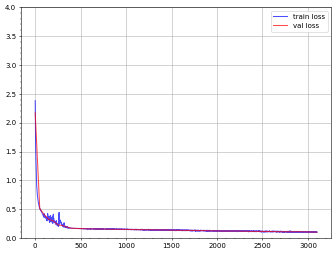

  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
# training! NRU.forward dispatches internally compiled 16-step chunks.
model = NRULM(config)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
train(model, optimizer, seq_len, batch_size, total_steps, max_grad_norm=None)

In [ ]:
# Save
torch.save(model.state_dict(), 'models/NRULM_copying_memory.pt')

In [ ]:
# Load model
model = NRULM(config)
model.to(device)
model.load_state_dict(torch.load('models/NRULM_copying_memory.pt'))

<All keys matched successfully>

In [ ]:
# Evaluate full-sequence perplexity and accuracy on the final k recall positions.
ppl, loss = perplexity(model, seq_len, seq_len)
recall_correct = recall_total = 0
with torch.no_grad():
    for _ in tqdm(range(100)):
        xb, yb = get_batch('val', seq_len, batch_size=128)
        logits, _ = model(xb)
        recall_correct += (logits[:, -k:].argmax(dim=-1) == yb[:, -k:]).sum().item()
        recall_total += yb[:, -k:].numel()
recall_accuracy = recall_correct / recall_total
print("perplexity:", ppl, "loss:", loss, "recall accuracy:", recall_accuracy)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
model.eval()
xb, yb = get_batch('val', seq_len, batch_size=1)
prompt = xb[:, :k + dependency_length]  # memory, delay, and recall marker
generated = model.generate(prompt, max_new_tokens=k, temperature=0, use_cache=True)
print('memory to recall: ', decode(yb[0, -k:].tolist()))
print('model recall:     ', decode(generated[0, -k+1:-1].tolist()))

memory to recall:  3 6 1 8 3 1 4 2 1 6
model recall:      _ _ _ _ _ _ _ _
